In [1]:
import torchvision
# For image transforms
from torchvision import transforms
# For DATA SET
import torchvision.datasets as datasets
# For Pytorch methods
import torch
import torch.nn as nn
# For Optimizer
import torch.optim as optim
# FOR DATA LOADER
from torch.utils.data import DataLoader
from tqdm import tqdm # a nice progress bar

from denoising_diffusion_pytorch import Unet, GaussianDiffusion

# MLFlow Visualization
import mlflow
import mlflow.pytorch
from torchvision.utils import save_image
import torchvision.utils as utils

mlflow.set_experiment('mnist_diffusion')

import os
from torchvision.utils import save_image

In [2]:
# Hyperparameters
LEARNING_RATE = 4e-4
BATCH_SIZE = 128  # Batch size
N_EPOCHS = 100
IMAGE_SIZE = 28
TIME_STEPS = 1000
SAMPLING_TIMESTEPS = 250

In [3]:
# we define a tranform that converts the image to tensor
myTransforms = transforms.Compose([transforms.ToTensor()])

# the MNIST dataset is available through torchvision.datasets
print("loading MNIST digits dataset")
dataset = datasets.MNIST(root="dataset/", transform=myTransforms, download=True)
# let's create a dataloader to load the data in batches
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = datasets.MNIST(root='dataset/', train=False, download=False, transform=myTransforms)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

loading MNIST digits dataset


In [4]:
DIM = 32
DIM_MULTS = (1, 2, 5)

device = (
    'cuda' if torch.cuda.is_available()
    else 'cpu'
)

model = Unet(
    dim = DIM,
    dim_mults = DIM_MULTS,
    flash_attn = False,
    channels = 1
).to(device)

diffusion = GaussianDiffusion(
    model,
    image_size = IMAGE_SIZE,
    timesteps = TIME_STEPS,           # number of steps
    sampling_timesteps = SAMPLING_TIMESTEPS    # number of sampling timesteps (using ddim for faster inference [see ddim paper])
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

In [5]:
os.makedirs('images', exist_ok=True)
os.makedirs('checkpoints', exist_ok=True)

train_losses = []
val_losses = []
with mlflow.start_run():
    # implement training loop. You get the loss by calling the diffusion function
    # `loss = diffusion(training_images)`
    for epoch in range(N_EPOCHS):
        ####################
        ##### Training #####
        ####################
        model.train()
        total_train_loss = 0.0
        num_batches_train = 0
        # loop through batches of the dataset
        pbar = tqdm(loader)
        for batch_idx, (images, _) in enumerate(pbar):
            # sample a batch of data
            images = images.to(device)
            train_loss = diffusion(images)
            
            optimizer.zero_grad()
            train_loss.backward()
            optimizer.step()

            total_train_loss += train_loss.item()
            num_batches_train += 1

            pbar.set_postfix({
                'loss_train': train_loss
            })

        avg_train_loss = total_train_loss / num_batches_train
        train_losses.append(avg_train_loss)

        ######################
        ##### Validation #####
        ######################
        model.eval()
        total_val_loss = 0.0
        num_batches_val = 0
        with torch.no_grad():
            for images, _ in test_loader:
                images = images.to(device)
                val_loss = diffusion(images)

                total_val_loss += val_loss.item()
                num_batches_val += 1

        avg_val_loss = total_val_loss / num_batches_val
        val_losses.append(avg_val_loss)
            
        mlflow.log_metric('train_loss', avg_train_loss, step=epoch)
        mlflow.log_metric('val_loss', avg_val_loss, step=epoch)

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_losses': train_losses,
            'val_losses':  val_losses,
        }, f'checkpoints/checkpoint_epoch_{epoch}.pth')

        # you can obtain sampled images (i.e. the backward pass) by calling the sample function
        # `sampled_images = diffusion.sample(batch_size = 4)`
        samples_images = diffusion.sample(batch_size=4)
        path = f'images/epoch_{epoch}.png'
        save_image(samples_images, path)
        mlflow.log_artifact(path)

100%|█| 469/469 [15:40<00:00,  2.01s/it, loss_train=tensor(0.0538, grad_fn=<MeanBackwa


sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

100%|█| 469/469 [24:50<00:00,  3.18s/it, loss_train=tensor(0.0432, grad_fn=<MeanBackwa


sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

100%|█| 469/469 [15:41<00:00,  2.01s/it, loss_train=tensor(0.0510, grad_fn=<MeanBackwa


...

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

100%|█| 469/469 [14:58<00:00,  1.92s/it, loss_train=tensor(0.0391, grad_fn=<MeanBackwa


sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

  0%| | 2/469 [00:06<24:32,  3.15s/it, loss_train=tensor(0.0386, grad_fn=<MeanBackward


KeyboardInterrupt: 

Training stopped after 20 epochs / ~20.700 seconds (5.75h) due to time constrains and cooling problems.

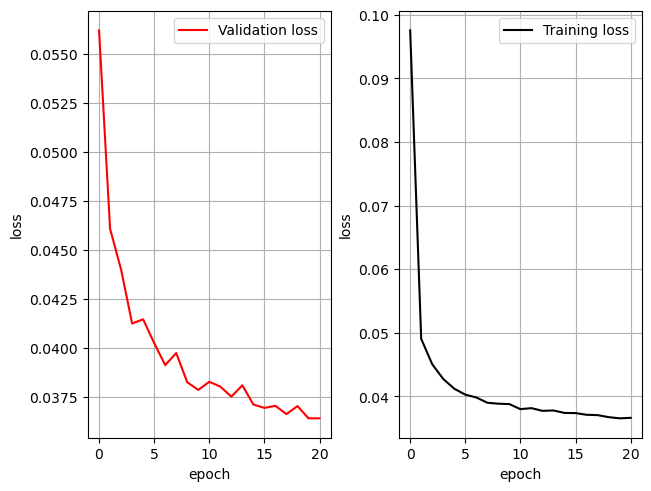

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, layout='constrained')

disc = pd.read_csv('train_loss.csv')
gen = pd.read_csv('val_loss.csv')

axs[0].plot(gen['step'], gen['value'], color='red', label='Validation loss')
axs[1].plot(disc['step'], disc['value'], color='black', label='Training loss')

axs[0].set(
    xlabel=('epoch'),
    ylabel=('loss'),
)
axs[1].set(
    xlabel=('epoch'),
    ylabel=('loss'),
)

axs[0].legend()
axs[0].grid(True)
axs[1].legend()
axs[1].grid(True)